In [1]:
import numpy as np 
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
  accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


/kaggle/input/taitanictrain/datasets_11657_16098_train.csv


In [2]:
df = pd.read_csv("/kaggle/input/taitanictrain/datasets_11657_16098_train.csv")

In [3]:
df.head()  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.sample(10)  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S
747,748,1,2,"Sinkkonen, Miss. Anna",female,30.0,0,0,250648,13.0000,NaN,S
757,758,0,2,"Bailey, Mr. Percy Andrew",male,18.0,0,0,29108,11.5000,NaN,S
668,669,0,3,"Cook, Mr. Jacob",male,43.0,0,0,A/5 3536,8.0500,NaN,S
416,417,1,2,"Drew, Mrs. James Vivian (Lulu Thorne Christian)",female,34.0,1,1,28220,32.5000,NaN,S
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31.0000,A31,C
711,712,0,1,"Klaber, Mr. Herman",male,NaN,0,0,113028,26.5500,C124,S
459,460,0,3,"O'Connor, Mr. Maurice",male,NaN,0,0,371060,7.7500,NaN,Q
727,728,1,3,"Mannion, Miss. Margareth",female,NaN,0,0,36866,7.7375,NaN,Q
448,449,1,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,NaN,C


In [6]:
df.shape 

(891, 12)

In [7]:
df.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
print(" Null Values:")
print(df.isnull() )

 Null Values:
     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  C

In [10]:
print(" Null Values:")
print(df.isnull().sum())

 Null Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [13]:
print(df['Cabin'].unique())

['Unknown' 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78'
 'D33' 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26'
 'C110' 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7'
 'C49' 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87'
 'B77' 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26'
 'C106' 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124'
 'C91' 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44'
 'A34' 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20'
 'B79' 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101'
 'C68' 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48'
 'E58' 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62 C64' 'E24'
 'C90' 'C45' 'E8' 'B101' 'D45' 'C46' 'D30' 'E121' 'D11' 'E77' 'F38' 'B3'
 'D6' 'B82 B84' 'D17' 'A36' 'B102' 'B69' 'E49' 'C47' 'D28' 'E17' 'A24'
 'C50' 'B42' 'C148']


In [14]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [15]:
df['Fare'].fillna(df['Fare'].median(), inplace=True)

In [16]:
print(" Null Values:")
print(df.isnull().sum())

 Null Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [17]:
df.dtypes   

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [18]:
object_cols = df.select_dtypes(include='object').columns
print("Object columns:", object_cols)

Object columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [19]:
df.describe()  

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
for col in df.columns:
    print(f"{col} - unique values: {df[col].nunique()}")

PassengerId - unique values: 891
Survived - unique values: 2
Pclass - unique values: 3
Name - unique values: 891
Sex - unique values: 2
Age - unique values: 88
SibSp - unique values: 7
Parch - unique values: 7
Ticket - unique values: 681
Fare - unique values: 248
Cabin - unique values: 148
Embarked - unique values: 3


In [21]:
df.duplicated().sum()    
df[df.duplicated()] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


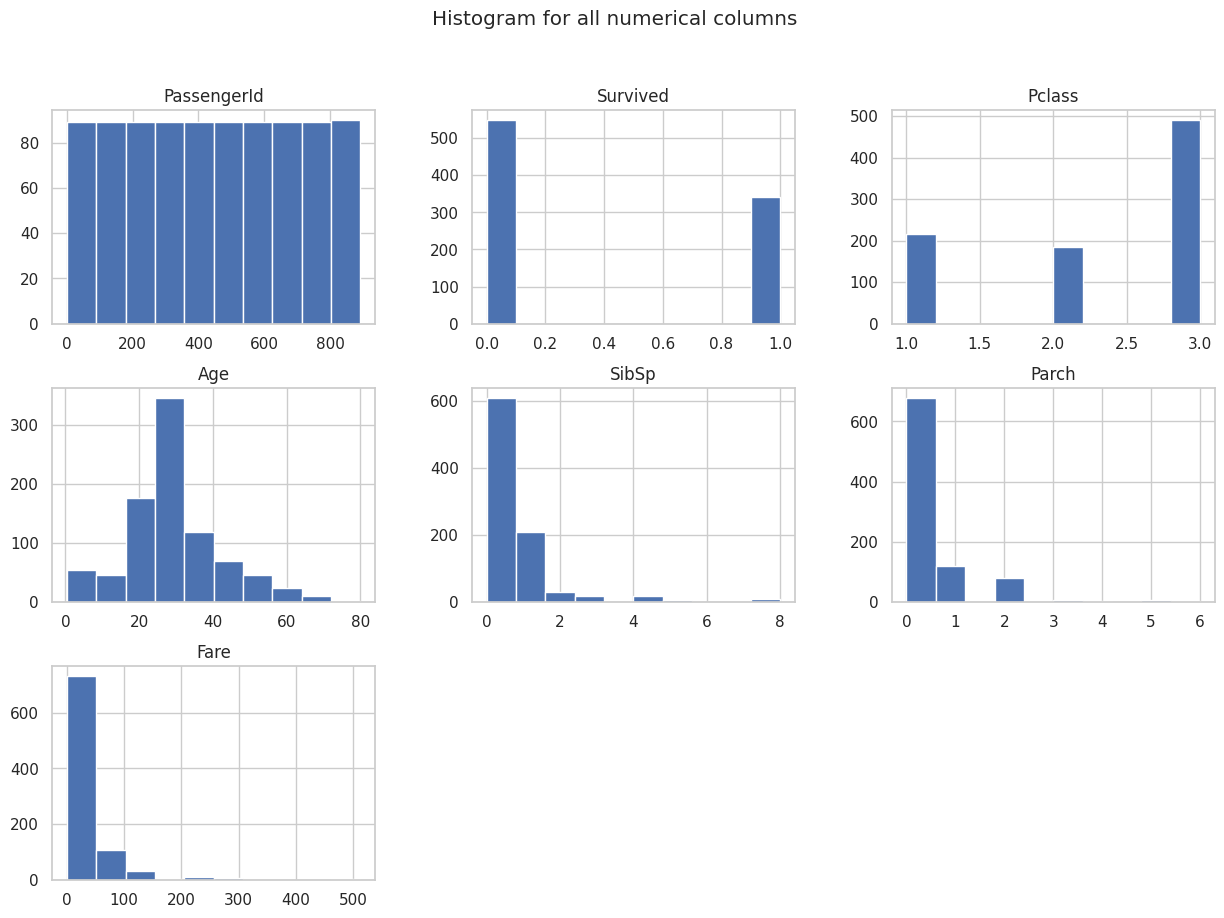

In [22]:
df.hist(figsize=(15, 10))
plt.suptitle("Histogram for all numerical columns")
plt.show()

In [23]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [24]:
df['Family_Size'] = df['SibSp'] + df['Parch']

In [25]:
print(df['Family_Size'].unique())

[1 0 2]


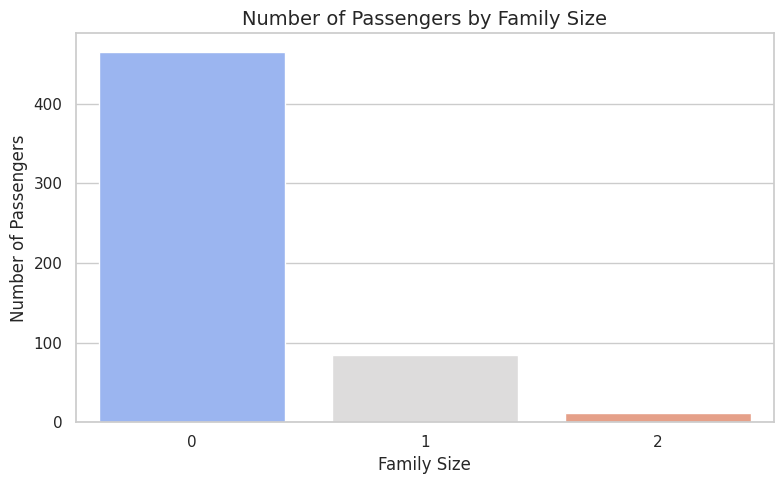

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Family_Size', palette='coolwarm')
plt.title("Number of Passengers by Family Size", fontsize=14)
plt.xlabel("Family Size", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.tight_layout()
plt.show()


In [27]:

df['Is_Alone'] = (df['Family_Size'] == 0).astype(int)

In [28]:
print(df['Is_Alone'].unique())

[0 1]


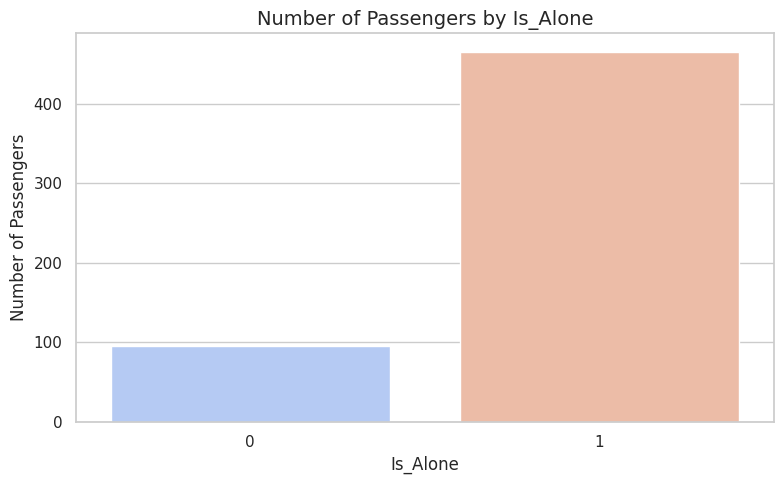

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Is_Alone', palette='coolwarm')
plt.title("Number of Passengers by Is_Alone", fontsize=14)
plt.xlabel("Is_Alone", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
df['Deck'] = df['Cabin'].astype(str).str[0]

In [31]:
print(df['Deck'].unique())


['U' 'C' 'E' 'D' 'A' 'F' 'B' 'T']


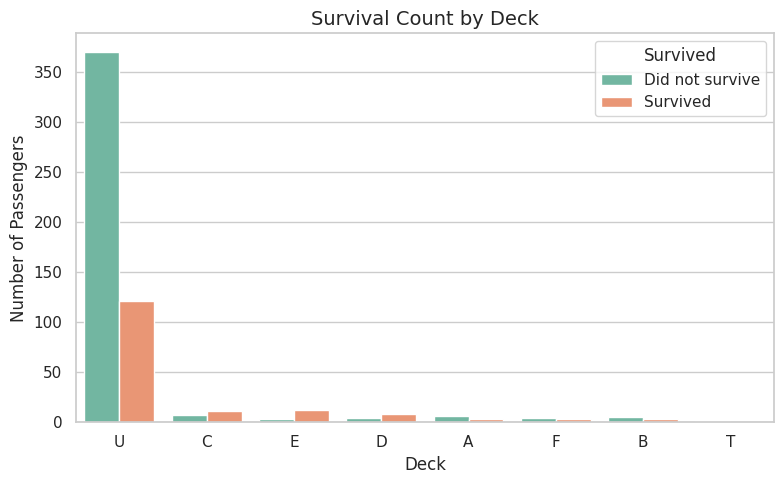

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Deck', hue='Survived', palette='Set2')
plt.title("Survival Count by Deck", fontsize=14)
plt.xlabel("Deck", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend(title="Survived", labels=["Did not survive", "Survived"])
plt.tight_layout()
plt.show()

In [33]:
df['Fare_Per_Person'] = df['Fare'] / (df['Family_Size'] + 1)


In [34]:
print(df['Fare_Per_Person'].unique())

[ 3.625       7.925      26.55        8.05        8.4583     51.8625
 15.0354      7.8542     13.          9.          7.225      26.
  8.0292     35.5         7.8792      7.8958     27.7208      7.75
  7.2292      6.          5.62085     4.7375     10.5         7.2264
  8.9         7.8         8.1583      2.8875      7.2271      7.65
 12.475       9.5         7.7875     47.1         8.6542      2.64166667
  7.775      12.075      52.          4.9125     14.4583      7.1417
  6.975       7.05        7.25       15.0458      9.2167      6.75
 11.5         7.7958     12.525       7.3125      7.7333      8.6625
 15.75       25.925      28.7125      0.         15.05       50.
  3.9271      6.4958     18.7875     31.         21.          3.875
 13.5         9.35        7.55       12.275       7.125       3.8875
 12.875       8.85       30.5        12.35       12.         14.
 28.5         9.225      35.         13.8604      3.2479      4.0125
  7.7292     12.65        6.8583      7.875      

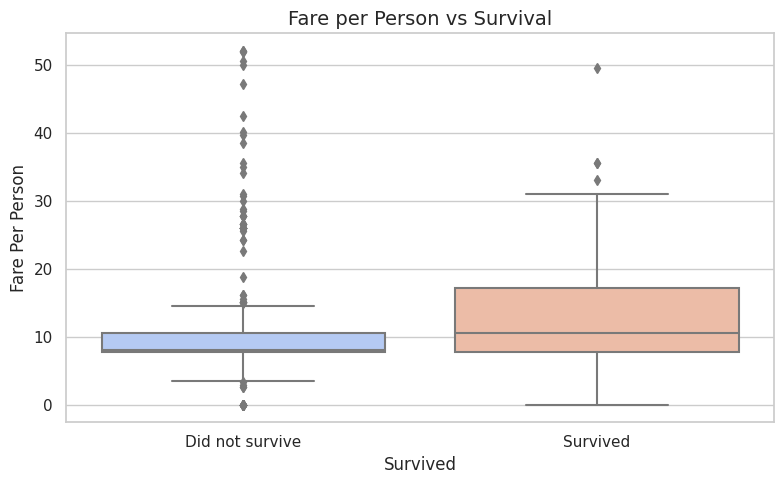

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Survived', y='Fare_Per_Person', palette='coolwarm')
plt.title("Fare per Person vs Survival", fontsize=14)
plt.xlabel("Survived", fontsize=12)
plt.ylabel("Fare Per Person", fontsize=12)
plt.xticks([0,1], ['Did not survive', 'Survived'])
plt.tight_layout()
plt.show()

In [36]:
df['Age_Pclass'] = df['Age'] * df['Pclass']


In [37]:
print(df['Age_Pclass'].unique())

[ 66.   78.   35.  105.   84.   54.   28.   60.   42.   56.   93.   70.
  68.   45.   40.   63.  120.   57.   58.   85.5  64.   75.   90.   87.
  34.   72.   99.  111.  114.   47.   43.5  51.   65.   36.  135.  141.
  50.   46.   37.   48.   81.  102.   80.  108.   38.   44.  136.5  96.
 153.   61.5  88.   70.5  45.5 126.   69.   76.   92.  117.  132.   62.
  52.   30.  100.  150.  121.5  53.   94.   74.  147.   27.   32.  129.
  31.   73.5 104.   24.   33.   19.  123.   91.5 144.   15.   39.   29.
  49.  103.5  26. ]


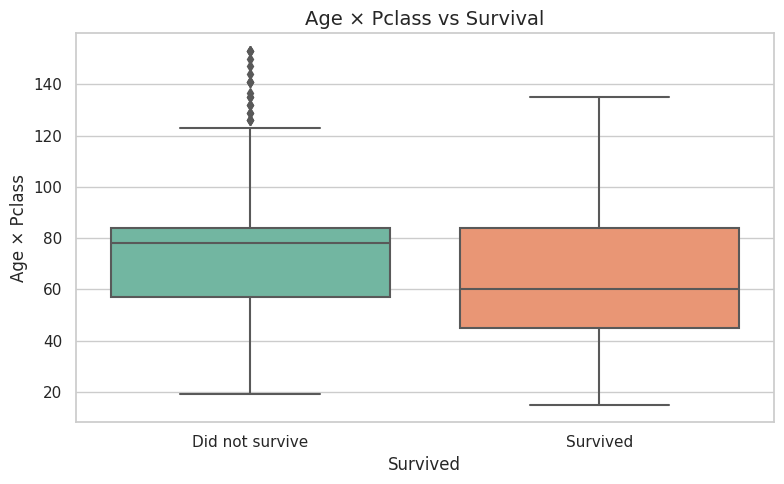

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Survived', y='Age_Pclass', palette='Set2')
plt.title("Age × Pclass vs Survival", fontsize=14)
plt.xlabel("Survived", fontsize=12)
plt.ylabel("Age × Pclass", fontsize=12)
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.tight_layout()
plt.show()

In [39]:
# حذف الأعمدة الغير رقمية واللي مش هنستخدمها
X = df[['Pclass', 'Age', 'Fare', 'Family_Size', 'Is_Alone', 'Fare_Per_Person', 'Age_Pclass']]
y = df['Survived']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [42]:
knn = KNeighborsClassifier(n_neighbors=5)  # ممكن نغير الرقم ده بعدين
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [43]:
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.650887573964497

Confusion Matrix:
 [[101  20]
 [ 39   9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.83      0.77       121
           1       0.31      0.19      0.23        48

    accuracy                           0.65       169
   macro avg       0.52      0.51      0.50       169
weighted avg       0.60      0.65      0.62       169

